In [34]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt  
from scipy.optimize import minimize, Bounds
from functools import partial
from scipy.stats import spearmanr
import json 

np.random.seed(123453)

### Data

In [35]:
data = pd.read_csv('Data/data2024.csv')
data

,page_name,num_posts,Trump_positive,Trump_negative,Trump_neutral,Kamala_positive,Kamala_negative,Kamala_neutral,Vance_positive,Vance_negative,...,Walz_negative,Walz_neutral,media_type,media_bias,bias_value,factual_reporting,factual_value,comment,country,sentiment_bias
0,ConservativeNewsDly,3020,33,154,399,20,167,152,0,2,...,20,8,website,extreme right,NaN,mixed,NaN,NaN,USA,0.043750
1,NEWSMAX,2860,114,398,440,36,379,202,8,7,...,67,24,TV station,right,7.8,low,7.6,NaN,USA,0.072557
2,WashingtonExaminer,2439,26,228,247,47,234,179,1,10,...,59,17,magazine,right-center,3.8,mostly factual,2.2,NaN,USA,0.025496
3,NewsNationNow,1877,8,177,342,47,40,240,3,12,...,7,23,TV station,least biased,1.2,high,1.1,NaN,USA,-0.196371
4,Breitbart,1552,106,198,112,8,455,32,6,9,...,33,2,website,right,8.1,mixed,6.4,NaN,USA,0.396285
5,TheHill,1358,5,167,41,65,50,87,7,35,...,13,34,newspaper,least biased,0.4,mostly factual,2.2,NaN,USA,-0.381308
6,nytimes,1194,4,314,98,78,31,154,0,9,...,3,18,newspaper,left-center,-4.1,high,1.4,NaN,USA,-0.515110
7,ABCNews,1007,2,118,75,77,34,178,2,6,...,2,24,TV station,left-center,-3.3,high,1.1,NaN,USA,-0.320826
8,FoxNews,966,18,73,43,22,188,74,6,17,...,62,10,TV station/website,right,6.7,mixed,6.1,NaN,USA,0.293006
9,NBCNews,932,4,235,99,39,33,103,0,20,...,4,13,TV station,left-center,-3.6,high,1.0,NaN,USA,-0.455806


In [36]:
data["num_posts"].sum()

38151

Data preparation:

In [37]:
n_media_outlets = data.shape[0]
subjects = ['Trump', 'Kamala', 'Vance', 'Walz']
n_subjects = len(subjects)

In [38]:
data = data.head(n = n_media_outlets).copy()
media_outlets = data['page_name'].to_list()
media_bias_label = data['media_bias'].to_list()
media_bias_value = data['bias_value'].to_list()

Data matrix:

In [39]:
mentions_matrix = np.zeros(shape = [n_media_outlets, n_subjects, 3])
for i in range(n_media_outlets):
    for j in range(n_subjects):
        mentions_matrix[i][j] = np.array(data.iloc[i][[f'{subjects[j]}_negative', f'{subjects[j]}_neutral', f'{subjects[j]}_positive']].to_list())

### Inference of data

In [40]:
def negative_log_likelihood(x, mentions_matrix):

    """ Function to minimize """

    n_rows = mentions_matrix.shape[0]
    n_cols = mentions_matrix.shape[1]

    z, a, b = x[:n_rows], x[n_rows:(n_rows + n_cols)], x[(n_rows + n_cols):]
    
    logl = 0.00
    for i in range(n_rows):
        for j in range(n_cols):
            z_ij = z[i] * a[j] + b[j]
            N_ij = np.sum(mentions_matrix[i][j])
            logl += (mentions_matrix[i][j][2] - mentions_matrix[i][j][0]) * z_ij - N_ij * (np.log(np.exp(z_ij) + 1 + np.exp(-z_ij)))        
    
    for i in range(n_rows):
        logl -= 0.5*(z[i]**2)
    
    for j in range(n_cols):
        logl -= 0.5 *(a[j]**2 + b[j]**2)
    
    return -logl

In [41]:
def grad_negative_log_likelihood(x, mentions_matrix):
    
    """ Gradient of function to minimize """

    n_rows = mentions_matrix.shape[0]
    n_cols = mentions_matrix.shape[1]

    z, a, b = x[:n_rows], x[n_rows:(n_rows + n_cols)], x[(n_rows + n_cols):]
    
    grad_z = np.zeros(n_rows)
    grad_a = np.zeros(n_cols)
    grad_b = np.zeros(n_cols)
    
    for i in range(n_rows):
        for j in range(n_cols):
            z_ij = z[i] * a[j] + b[j]
            N_ij = np.sum(mentions_matrix[i][j])
            W_ij = (mentions_matrix[i][j][2] - mentions_matrix[i][j][0]) - N_ij * (np.exp(z_ij) - np.exp(-z_ij)) / (np.exp(z_ij) + 1 + np.exp(-z_ij))
            grad_z[i] += W_ij * a[j]
        grad_z[i] -= z[i]
    
    for j in range(n_cols):
        for i in range(n_rows):
            z_ij = z[i] * a[j] + b[j]
            N_ij = np.sum(mentions_matrix[i][j])
            W_ij = (mentions_matrix[i][j][2] - mentions_matrix[i][j][0]) - N_ij * (np.exp(z_ij) - np.exp(-z_ij)) / (np.exp(z_ij) + 1 + np.exp(-z_ij))
            grad_a[j] += W_ij * z[i]
            grad_b[j] += W_ij
        
        grad_a[j] -= a[j]
        grad_b[j] -= b[j]
    
    return -np.hstack([grad_z, grad_a, grad_b])

In [42]:
partial_negative_log_likelihood = partial(negative_log_likelihood, mentions_matrix = mentions_matrix)
partial_grad_negative_log_likelihood = partial(grad_negative_log_likelihood, mentions_matrix = mentions_matrix)

Optimizer:

In [43]:
# Bounds
lb = [-5] * (n_media_outlets + 2 * n_subjects)
ub = [5] * (n_media_outlets + 2 * n_subjects)
bounds = Bounds(lb, ub)

solution = minimize(
    fun=partial_negative_log_likelihood,
    x0=np.random.normal(size = (n_media_outlets + 2 * n_subjects)),
    method='L-BFGS-B',
    jac=partial_grad_negative_log_likelihood,
    bounds=bounds,
    tol=10**-6
)

print(solution)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 18526.096348368083
        x: [ 2.395e-01  3.127e-01 ... -7.800e-01 -6.765e-01]
      nit: 96
      jac: [-7.314e-03 -8.915e-01 ...  1.953e-01  3.291e-01]
     nfev: 107
     njev: 107
 hess_inv: <48x48 LbfgsInvHessProduct with dtype=float64>


In [44]:
z_predicted, a_predicted, b_predicted = solution.x[:n_media_outlets], solution.x[n_media_outlets:(n_media_outlets + n_subjects)], solution.x[(n_media_outlets + n_subjects):]

Data frames value predicted:

In [45]:
z_media_outlets = pd.DataFrame()
z_media_outlets['outlet'] = media_outlets
z_media_outlets['z'] = [z for z in z_predicted]
z_media_outlets['media_bias_label'] = media_bias_label
z_media_outlets['media_bias_value'] = media_bias_value

In [46]:
z_media_outlets.sort_values(by = 'z', inplace=True)

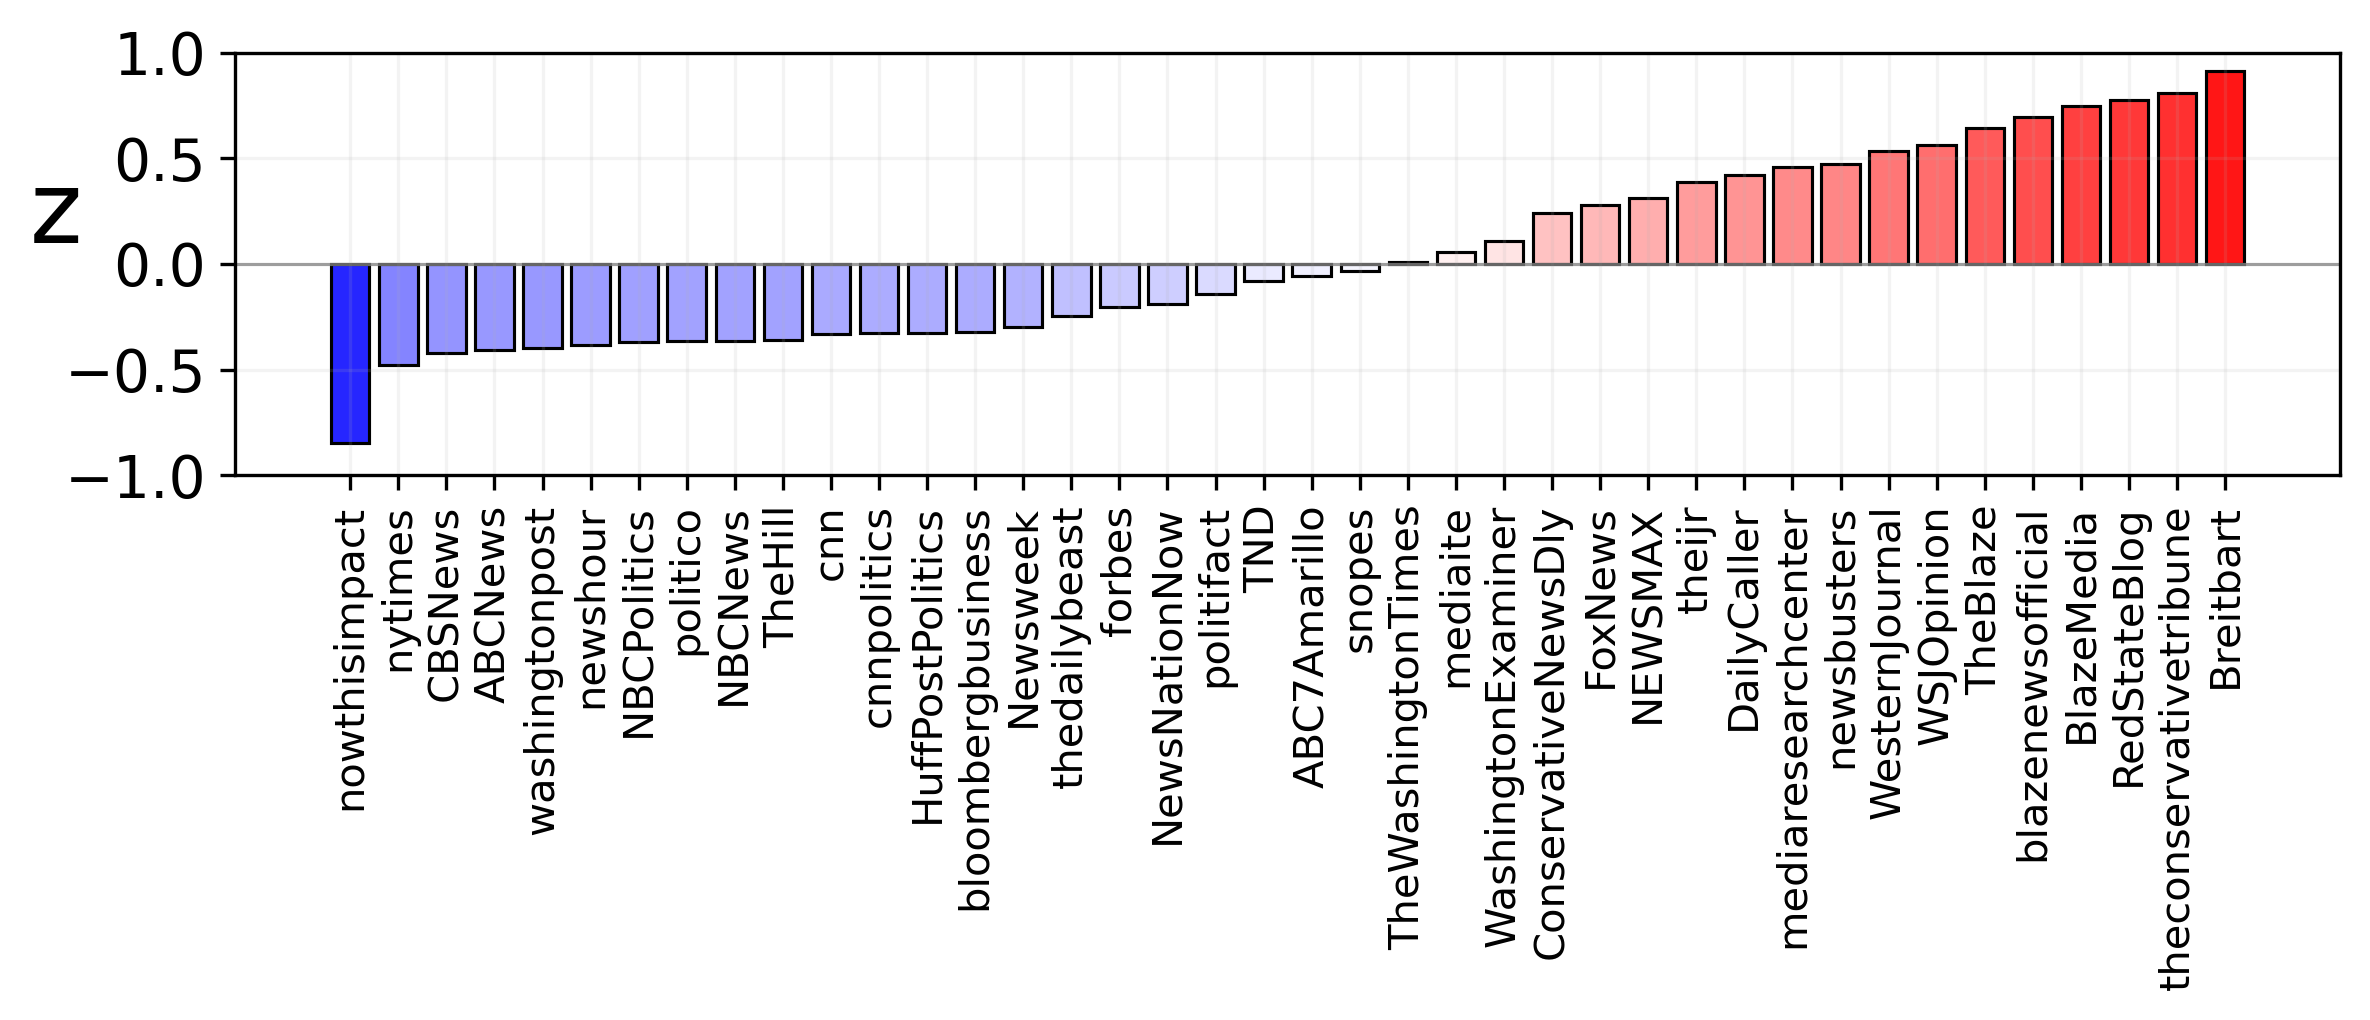

In [47]:
plt.figure(figsize = (8,3.5), dpi = 300)

# Normalize the values to the range [0, 1]
norm = plt.Normalize(-1, 1)

# Choose a colormap
cmap = plt.cm.bwr
color = cmap(norm(z_media_outlets['z']))

plt.bar(range(z_media_outlets.shape[0]), height=z_media_outlets['z'], color = color, linewidth = 0.75, edgecolor = 'k')
plt.xticks(range(z_media_outlets.shape[0]), z_media_outlets['outlet'], rotation = 90, size = 10)
plt.axhline(0.00, color = 'grey', linewidth = 0.75, alpha = 0.75)
plt.ylabel('z', size = 24, rotation = 0, labelpad = 2)
plt.grid(True, alpha = 0.15)
plt.yticks([-1, -0.5, 0, 0.5, 1], size = 14)
plt.ylim([-1, 1])
plt.tight_layout()
#plt.savefig('images/Media_model_score.pdf')
plt.show()

In [48]:
ab_subjects = pd.DataFrame()
ab_subjects['subject'] = subjects
ab_subjects['a'] = [a for a in a_predicted]
ab_subjects['b'] = b_predicted

In [49]:
ab_subjects.sort_values('a', inplace=True)
ab_subjects

,subject,a,b
3,Walz,-1.965114,-0.676543
1,Kamala,-1.886841,-0.531749
0,Trump,0.660341,-0.863246
2,Vance,0.676611,-0.780025


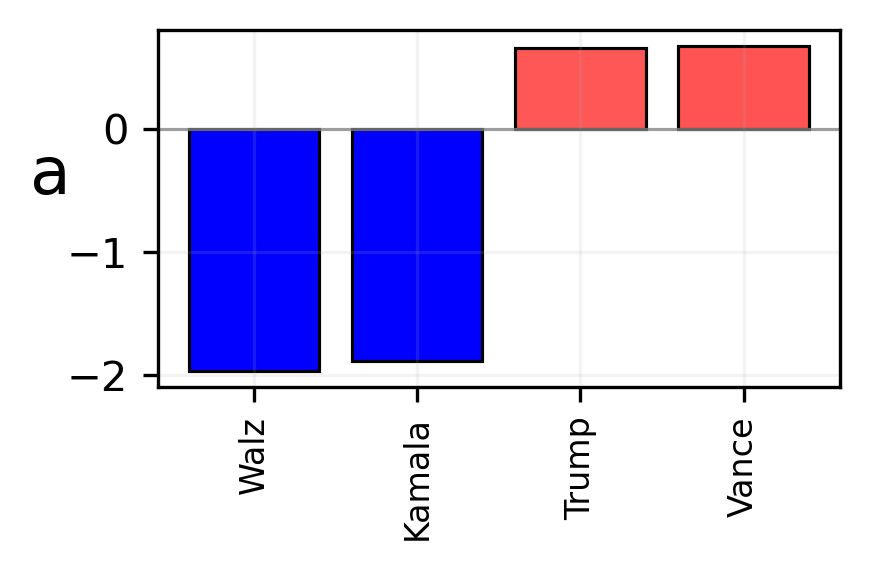

In [50]:
plt.figure(figsize = (3,2), dpi = 300)

plt.bar(range(ab_subjects.shape[0]), height=ab_subjects['a'], color = cmap(norm(ab_subjects['a'])), linewidth = 0.75, edgecolor = 'k')
plt.xticks(range(ab_subjects.shape[0]), ab_subjects['subject'], rotation = 90, size = 8)
plt.axhline(0.00, color = 'grey', linewidth = 0.75, alpha = 0.75)
plt.ylabel('a', size = 16, rotation = 0)
plt.grid(True, alpha = 0.15)
plt.tight_layout()
#plt.savefig('images/Candidates_coefficients.pdf')
plt.show()

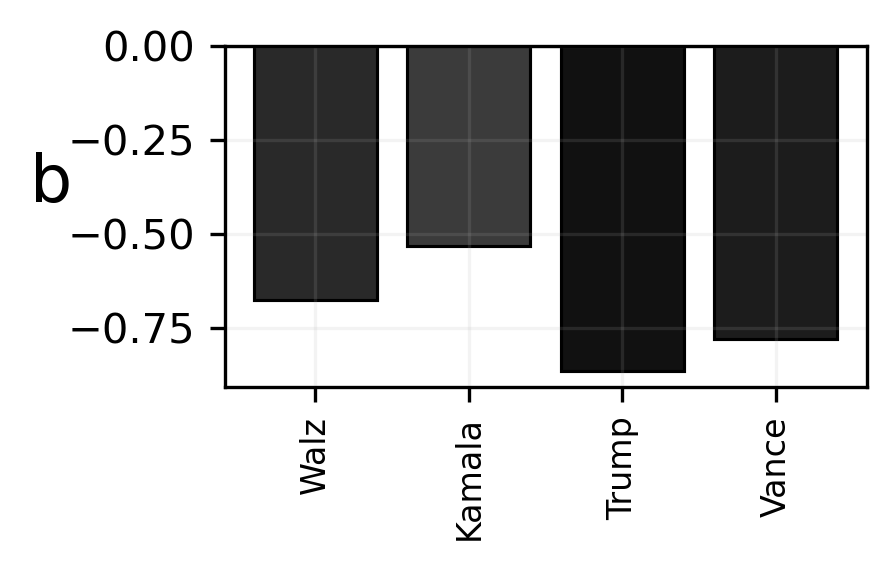

In [51]:
plt.figure(figsize = (3,2), dpi = 300)

plt.bar(range(ab_subjects.shape[0]), height=ab_subjects['b'], color = plt.cm.gray(norm(ab_subjects['b'])), linewidth = 0.75, edgecolor = 'k')
plt.xticks(range(ab_subjects.shape[0]), ab_subjects['subject'], rotation = 90, size = 8)
plt.axhline(0.00, color = 'grey', linewidth = 0.75, alpha = 0.75)
plt.ylabel('b', size = 16, rotation = 0)
plt.grid(True, alpha = 0.15)
plt.tight_layout()
#plt.savefig('images/Candidates_biases.pdf')
plt.show()

### $z_{ij}$

In [52]:
z_matrix = np.zeros(shape = [n_media_outlets, n_subjects])
for i in range(n_media_outlets):
    for j in range(n_subjects):
        z_matrix[i][j] = ab_subjects['a'].iloc[j] * z_media_outlets['z'].iloc[i] + ab_subjects['b'].iloc[j]

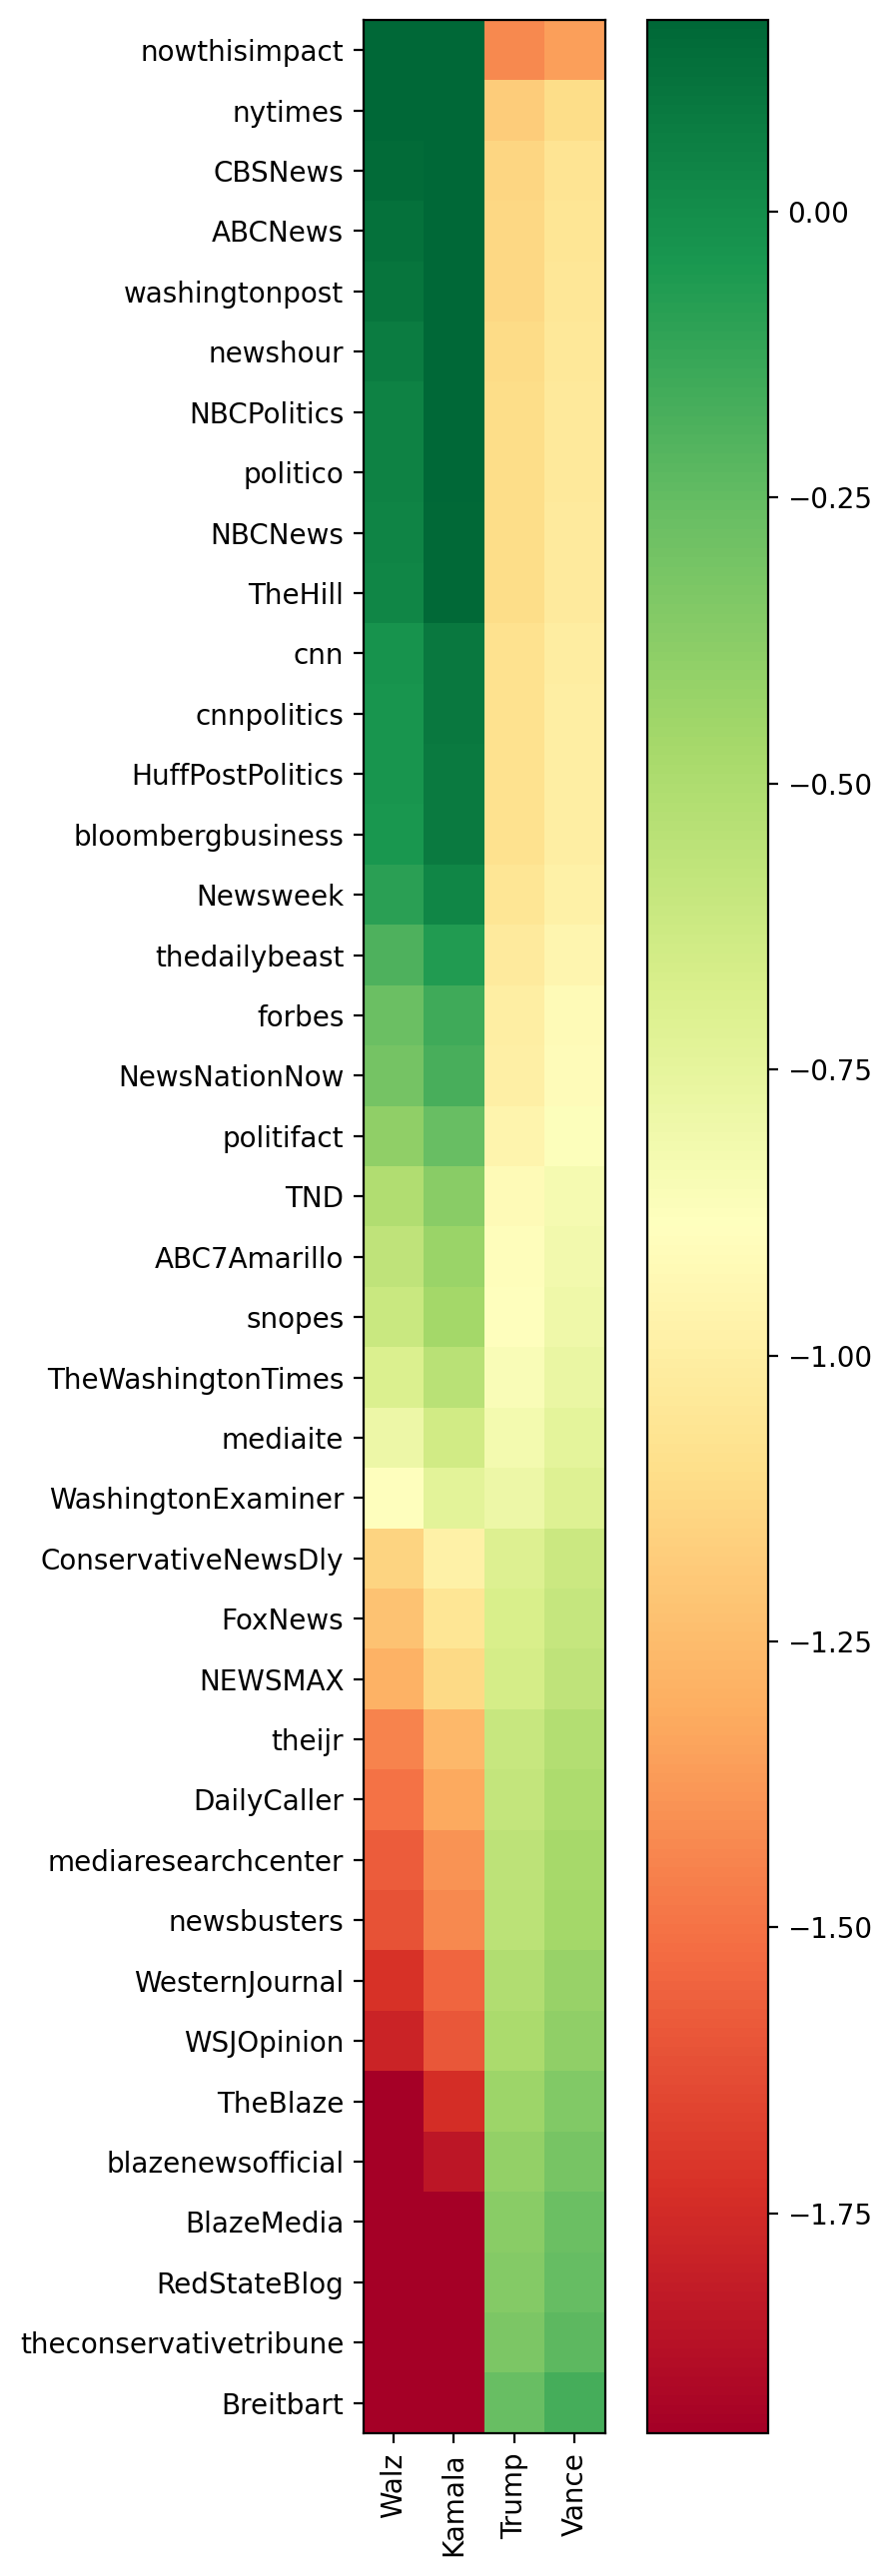

In [53]:
plt.figure(figsize=(5,13), dpi = 200)
plt.imshow(z_matrix, vmin=np.quantile(z_matrix.ravel(), q = 0.05), vmax=np.quantile(z_matrix.ravel(), q = 0.95), cmap='RdYlGn')
plt.yticks(range(z_media_outlets.shape[0]), z_media_outlets['outlet'])
plt.xticks(range(ab_subjects.shape[0]), ab_subjects['subject'], rotation = 90)
plt.colorbar()
plt.tight_layout()
plt.show()

### Plots 

In [54]:
z_media_outlets_without_nans = z_media_outlets.dropna()
z_media_outlets_without_nans['media_bias_label'].unique()

<StringArray>
[    'far left',  'left-center', 'least biased',         'left',
 'right-center',        'right',    'far right']
Length: 7, dtype: str

In [55]:
z_media_outlets

,outlet,z,media_bias_label,media_bias_value
38,nowthisimpact,-0.848256,far left,-8.5
6,nytimes,-0.480366,left-center,-4.1
13,CBSNews,-0.421070,left-center,-3.3
7,ABCNews,-0.405254,left-center,-3.3
14,washingtonpost,-0.399620,left-center,-3.6
23,newshour,-0.382825,left-center,-2.4
10,NBCPolitics,-0.369891,left-center,-3.6
39,politico,-0.366829,left-center,-2.8
9,NBCNews,-0.365078,left-center,-3.6
5,TheHill,-0.362311,least biased,0.4


In [56]:
markerdict = {'far right': '>', 'extreme right': '>', 'right': '>', 'right-center': '>', 'left-center': '<', 'least biased': 's', 'left': '<', 'far left': '<'}
colordict = {'far right': 'darkred', 'extreme right': 'darkred', 'right': 'red', 'right-center': 'lightcoral', 'left-center': 'lightblue', 'left': 'blue', 'least biased': 'gray', 'far left': 'darkblue'}

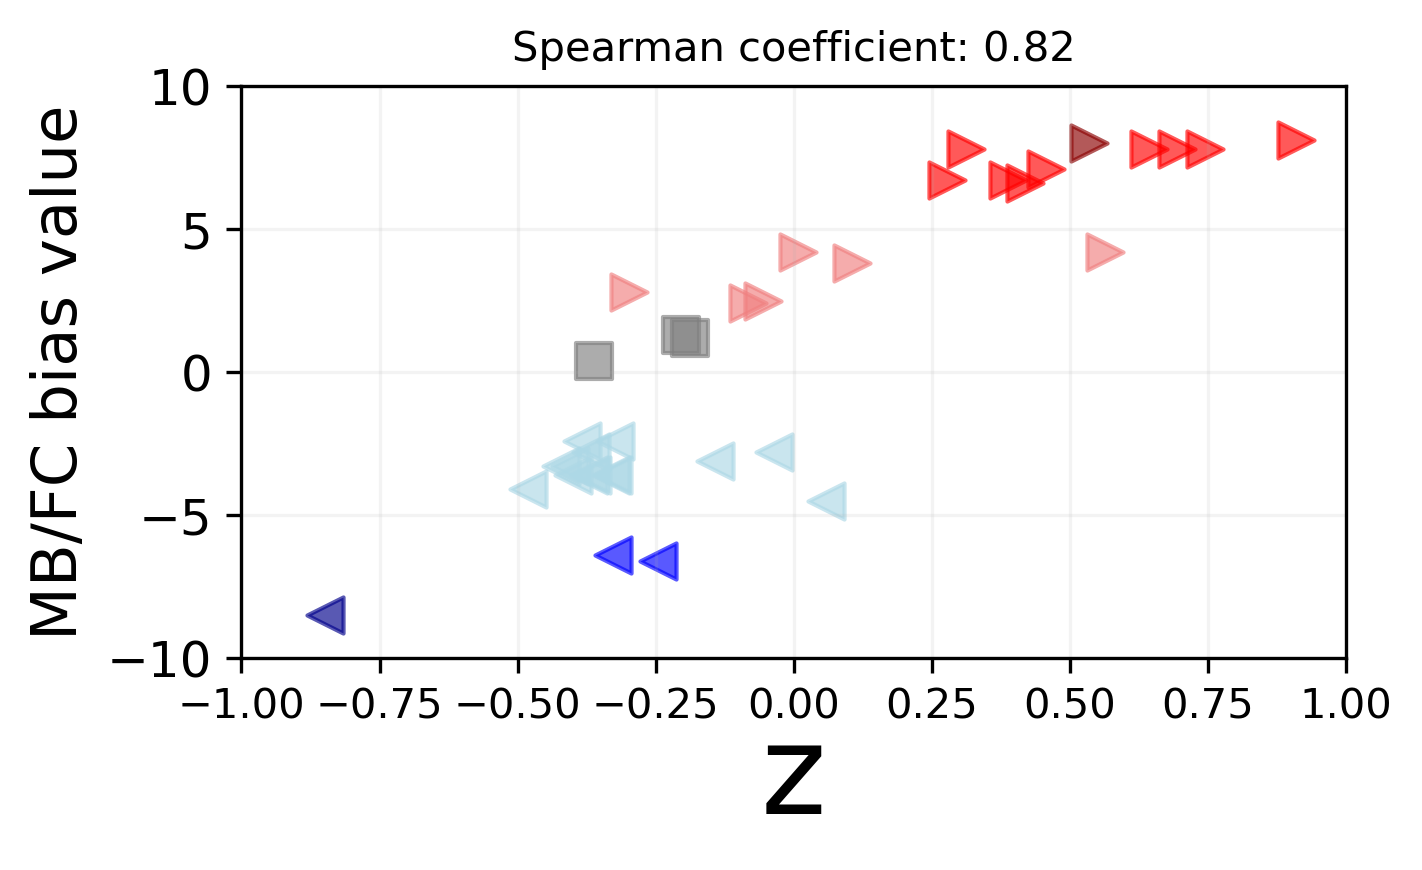

In [57]:
plt.figure(figsize = (5,3), dpi = 300)

for i in range(z_media_outlets_without_nans.shape[0]):
    plt.scatter(z_media_outlets_without_nans['z'].iloc[i], z_media_outlets_without_nans['media_bias_value'].iloc[i], 
            marker = markerdict[z_media_outlets_without_nans['media_bias_label'].iloc[i]], 
                color = colordict[z_media_outlets_without_nans['media_bias_label'].iloc[i]], s = 75, alpha = 0.65)
plt.xlabel('z', size = 30, labelpad = -2)
plt.xticks(size = 10)
plt.yticks(size = 12)
plt.ylabel('MB/FC bias value', size = 15)
plt.grid(True, alpha = 0.15)
plt.xlim([-1, 1])
plt.ylim([-10, 10])
plt.title("Spearman coefficient: {:.2f}".format(spearmanr(z_media_outlets_without_nans['z'], z_media_outlets_without_nans['media_bias_value']).statistic), size = 10)
plt.tight_layout()
#plt.savefig('images/Media_bias_fact_check_comparison.pdf')
plt.show()